# NEW SYSTEM

In [31]:
#user = r"\SagixOffice"  # HomeOffice
user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import src.transitions as tr
import src.fluorophores as fl
import src.statistics as st
import src.simulation as si
import src.emissions as em
import src.blinking as bl
import src.tcspc as tc
import src.fcs as fc

import numpy as np

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Setup the fluorophores

In [2]:
fluorophores = fl.construct_fluorophores('cy5', 10, 4)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

(<Figure size 600x300 with 1 Axes>,
 array([[<AxesSubplot:xlabel='x [nm]', ylabel='y [nm]'>]], dtype=object))

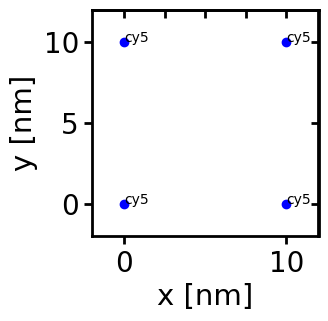

In [3]:
fluorophore_system.plot()

### Setup the transitions

In [4]:
transitions = tr.load_transitions(fluorophore_system, 2.5, 540)

In [5]:
transition_set = tr.TransitionSet(transitions, fluorophore_system)

In [6]:
transition_set = transition_set.filter_by_abbreviation(remove_list=['HFRET', 'CFRET', 'OFRET', 'TFRET'])

In [7]:
transition_set.adjust_rates({'HFRET(42.4)': 5e5})

In [8]:
transition_set.finalize()

(<Figure size 600x400 with 1 Axes>, <AxesSubplot:>)

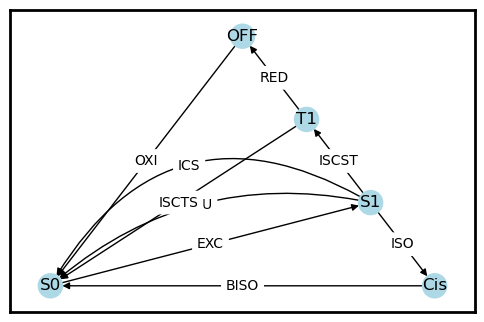

In [9]:
transition_set.plot(graph_type='planar')

### Prediction

In [10]:
prediction = st.Prediction(transition_set)

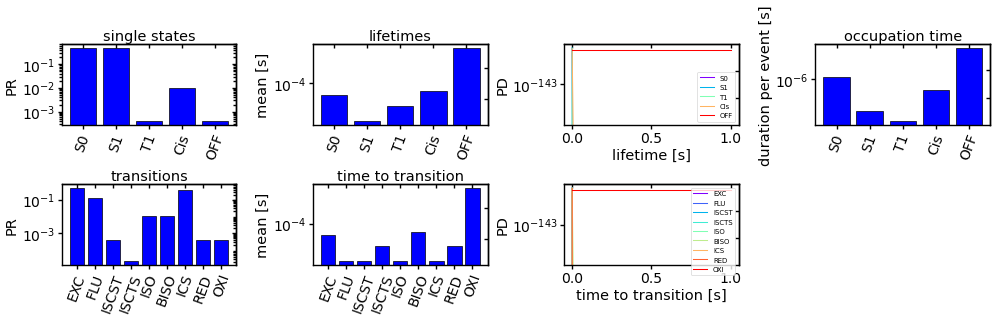

In [83]:
prediction.plot_all()

### Simulation

In [33]:
simulation = si.Simulation(transition_set)

In [39]:
simulation.run(size=int(1e6), end_time=None, seed=3)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


### Analysis

In [15]:
analysis = st.Analysis(simulation)

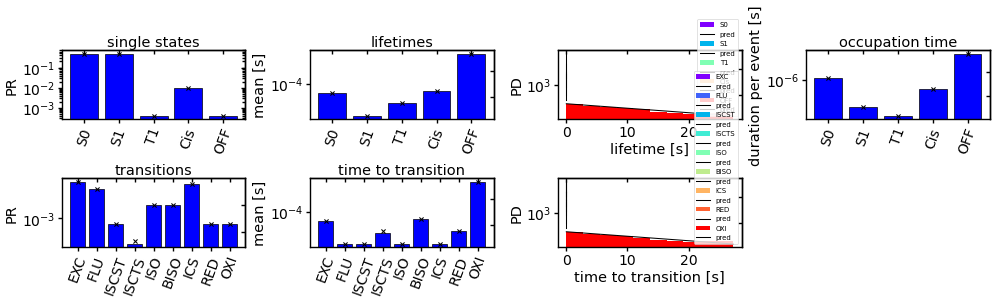

In [16]:
analysis.plot_all(prediction=prediction)

### Emissions

In [17]:
emissions = em.Emissions(simulation, photon_collection_rate=1, resample='4ms', emccd_gain=10, seed=100)

(<Figure size 600x300 with 1 Axes>,
 array([[<AxesSubplot:title={'center':'intensity distribution'}, xlabel='photon count', ylabel='PD'>]],
       dtype=object))

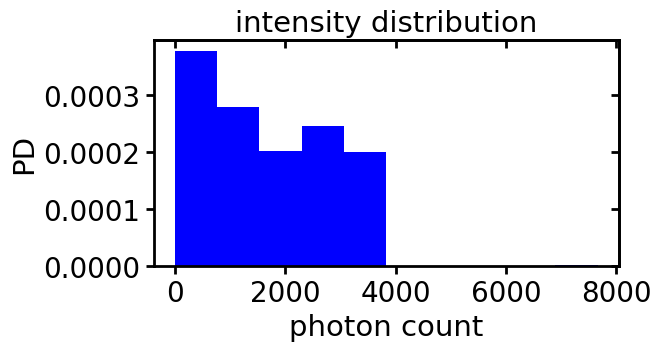

In [18]:
emissions.plot(mode='histogram')

(<Figure size 600x300 with 1 Axes>,
 array([[<AxesSubplot:title={'center':'fluorescence trajectory'}, xlabel='time [s]', ylabel='photon count'>]],
       dtype=object))

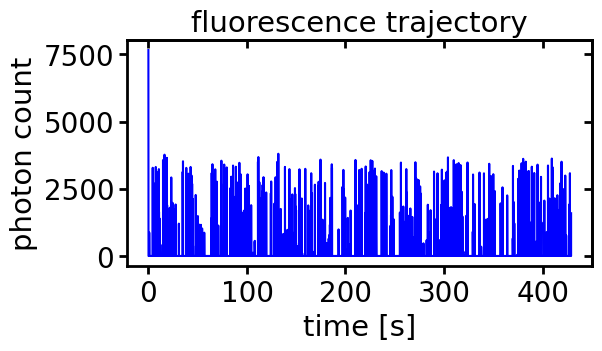

In [19]:
emissions.plot(mode='')

### fcs

In [20]:
fcs = fc.FCS(emissions).autocorrelate_time_points(exp_min=-8, exp_max=2)

(<Figure size 600x300 with 1 Axes>,
 array([[<AxesSubplot:title={'center':'$\\tau_{min} = 1.39e-08$ s'}, xlabel='$\\tau [s]$', ylabel='$G(\\tau)$'>]],
       dtype=object))

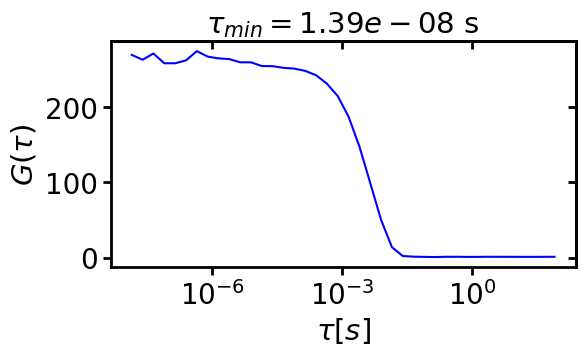

In [21]:
fcs.plot()

### blinking

In [22]:
blinking = bl.Blinking(emissions)

(<Figure size 600x300 with 1 Axes>,
 array([[<AxesSubplot:title={'center':'OFF periods'}, xlabel='consecutive frames', ylabel='PD'>]],
       dtype=object))

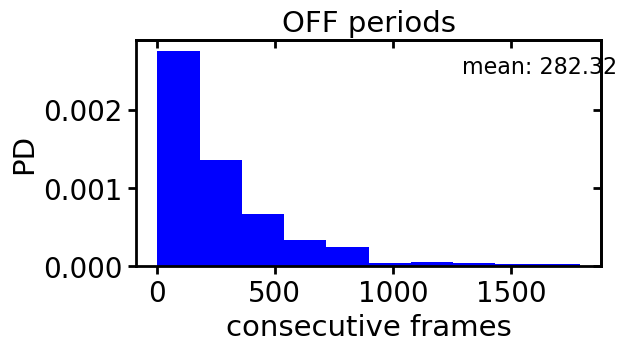

In [23]:
blinking.plot(mode='off_histogram')

### tcspc

In [24]:
tcspc = tc.TCSPC(transition_set)

In [25]:
tcspc.run(start_at=(0, 0, 0, 0), n_steps=1000, seed=100)

In [26]:
tcspc.get_observed_lifetimes()

(<Figure size 600x300 with 1 Axes>,
 array([[<AxesSubplot:xlabel='observed lifetime [s]', ylabel='PD'>]],
       dtype=object))

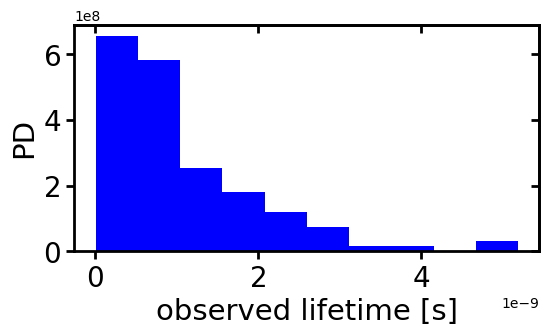

In [27]:
tcspc.plot()